# **Multi-Output Prediction System using Artificial Neural Networks (ANN)**

---

## **Project Objective**

The objective of this project is to develop a **Multi-Output Prediction System** using an **Artificial Neural Network (ANN)** capable of predicting multiple target variables simultaneously from a shared set of input features.

In many real-world scenarios, decisions depend on multiple outcomes rather than a single prediction. This project focuses on building a system that can learn shared representations and generate **multiple predictions in a single unified model**, improving efficiency and consistency.

The system is designed to:

- Predict **multiple outputs simultaneously** (multi-target learning)  
- Capture **shared patterns across different target variables**  
- Improve efficiency by avoiding separate models for each output  
- Demonstrate advanced deep learning techniques for structured data  

This project is highly applicable in:
- business analytics (e.g., revenue + churn + engagement)  
- healthcare prediction systems (multiple clinical outcomes)  
- financial modeling (risk, return, and probability metrics)  
- recommendation and decision-support systems  

---

## **Dataset Used**

This project utilizes structured datasets containing multiple target variables along with input features.

### **Dataset Sources**

- Kaggle multi-output datasets  
- synthetic datasets (if generated in your notebook)  
- enterprise-like structured datasets  

### **Dataset Characteristics**

The dataset includes:

- **Input features**, such as:
  - demographic data  
  - behavioral indicators  
  - numerical attributes  

- **Multiple target variables**, which may include:
  - classification outputs (e.g., churn, fraud)  
  - regression outputs (e.g., revenue, score)  

- Mixed data characteristics:
  - numerical and categorical features  
  - correlated outputs  
  - shared dependencies across targets  

Key characteristics:
- multi-dimensional output space  
- interdependent target variables  
- complex relationships between inputs and outputs  

### **How Dataset is Used in the Project**

The dataset is processed through a structured pipeline:

- **Data preprocessing**
  - handling missing values  
  - encoding categorical features  
  - scaling numerical variables  

- **Feature engineering**
  - transformation of inputs for better representation  

- **Multi-output preparation**
  - structuring multiple target variables  
  - aligning outputs for model training  

- **Train-validation-test split**
  - ensures generalization  
  - avoids overfitting  

- **Model training**
  - ANN trained to predict multiple outputs simultaneously  

The dataset enables the model to learn **shared and independent relationships across multiple targets**, which is essential for multi-output prediction.

---

## **Project Summary**

This project presents a complete implementation of a **Multi-Output Prediction System using Artificial Neural Networks**, focusing on predicting multiple target variables in a single model.

The workflow begins with preparing a structured dataset that includes both input features and multiple outputs. Data preprocessing ensures that features are properly encoded and scaled, while outputs are structured to align with the model architecture.

The core of the system is an **Artificial Neural Network**, designed with a shared representation layer that feeds into multiple output nodes. The model learns:
- shared feature representations across tasks  
- relationships between inputs and multiple outputs  
- dependencies among target variables  

The ANN architecture includes:
- input layer representing shared features  
- hidden layers capturing complex interactions  
- output layer with multiple nodes corresponding to different targets  

A key strength of this project is its ability to **leverage shared learning**, where knowledge gained from one prediction task improves performance on others.

Evaluation is performed using:
- classification metrics (accuracy, precision, recall, F1-score) for categorical outputs  
- regression metrics (MAE, MSE, RMSE) for continuous outputs  

The system can be used in real-world applications to:
- reduce model complexity (single model vs multiple models)  
- improve consistency across predictions  
- support multi-dimensional decision-making  

Additionally, the project enables **joint prediction analysis**, allowing users to study relationships between different outputs.

Overall, this project demonstrates advanced deep learning techniques for structured data, showcasing the ability to build **efficient, scalable, and multi-dimensional prediction systems**.

---

## **Key Highlights**

- Built a **Multi-Output Prediction system using ANN**, targeting advanced analytics.

- Implemented **multi-target learning**, predicting:
  - multiple classification outputs  
  - multiple regression outputs  

- Utilized structured datasets with:
  - shared input features  
  - multiple target variables  

- Developed a complete **data preprocessing pipeline**, including:
  - missing value handling  
  - encoding  
  - scaling  

- Designed an **ANN architecture**, capable of:
  - shared representation learning  
  - simultaneous prediction of multiple outputs  

- Leveraged **shared learning across tasks**, improving:
  - efficiency  
  - model performance  

- Evaluated model performance using:
  - classification metrics (accuracy, F1-score)  
  - regression metrics (MAE, RMSE)  

- Reduced complexity by:
  - replacing multiple models with a single unified model  

- Enabled **multi-dimensional decision support**, including:
  - combined insights across outputs  
  - improved business decision-making  

- Designed for **real-world deployment**, including:
  - business analytics systems  
  - healthcare prediction tools  
  - financial modeling platforms  

- Demonstrates strong expertise in:
  - **Artificial Neural Networks (ANN)**  
  - **multi-output learning**  
  - **advanced structured data modeling**

---


In [1]:
# =============================
# Cell 1: Basic Imports
# =============================
import os
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [2]:
# =============================
# Cell 2: Visualization Imports
# =============================
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [3]:
# =============================
# Cell 3: Scikit-learn Imports
# =============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.cluster import KMeans

In [4]:
# =============================
# Cell 4: TensorFlow / Keras Imports
# =============================
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

In [5]:
# =============================
# Cell 5: Reproducibility
# =============================
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [6]:
# =============================
# Cell 6: Project Paths
# =============================
PROJECT_DIR = Path.cwd()
ARTIFACTS_DIR = PROJECT_DIR / "multi_output_ann_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACTS_DIR / "multi_output_ann_model.keras"

print("Artifacts directory:", ARTIFACTS_DIR)

Artifacts directory: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Multi-Output Prediction System\multi_output_ann_artifacts


## 4. Business Scenario Definition

We simulate a company that wants to score every customer on three targets:
1. **Churn Probability**
2. **Predicted CLV**
3. **Predicted Engagement Score**

The system can then support:
- retention campaigns
- revenue planning
- customer success prioritization
- personalized offers

In [7]:
# =============================
# Cell 7: Synthetic Dataset Size
# =============================
N_SAMPLES = 15000
N_SAMPLES

15000

In [8]:
# =============================
# Cell 8: Generate Base Numeric Features
# =============================
age = np.random.randint(18, 75, size=N_SAMPLES)
tenure_months = np.random.randint(1, 121, size=N_SAMPLES)
monthly_income = np.random.normal(loc=6500, scale=2200, size=N_SAMPLES).clip(1200, 25000)
monthly_spend = np.random.normal(loc=420, scale=180, size=N_SAMPLES).clip(20, 2500)
transactions_last_30d = np.random.poisson(lam=8, size=N_SAMPLES).clip(0, 50)
avg_session_minutes = np.random.normal(loc=24, scale=10, size=N_SAMPLES).clip(1, 120)
products_owned = np.random.randint(1, 8, size=N_SAMPLES)
complaints_last_6m = np.random.poisson(lam=0.8, size=N_SAMPLES).clip(0, 10)
days_since_last_login = np.random.randint(0, 120, size=N_SAMPLES)
discount_usage_rate = np.random.beta(a=2.2, b=4.5, size=N_SAMPLES)
support_tickets_last_90d = np.random.poisson(lam=1.5, size=N_SAMPLES).clip(0, 20)
website_visits_last_30d = np.random.poisson(lam=14, size=N_SAMPLES).clip(0, 80)

In [9]:
# =============================
# Cell 9: Generate Categorical Features
# =============================
region = np.random.choice(
    ["North", "South", "East", "West", "Central"],
    size=N_SAMPLES,
    p=[0.22, 0.18, 0.20, 0.23, 0.17]
)

channel = np.random.choice(
    ["Web", "Mobile", "Store", "Partner"],
    size=N_SAMPLES,
    p=[0.38, 0.34, 0.17, 0.11]
)

plan_type = np.random.choice(
    ["Basic", "Standard", "Premium", "Enterprise"],
    size=N_SAMPLES,
    p=[0.36, 0.33, 0.22, 0.09]
)

segment = np.random.choice(
    ["Budget", "Growth", "Loyal", "HighValue"],
    size=N_SAMPLES,
    p=[0.30, 0.28, 0.24, 0.18]
)

device_type = np.random.choice(
    ["Android", "iOS", "Desktop", "Tablet"],
    size=N_SAMPLES,
    p=[0.34, 0.28, 0.28, 0.10]
)

In [10]:
# =============================
# Cell 10: Build Base DataFrame
# =============================
df = pd.DataFrame({
    "age": age,
    "tenure_months": tenure_months,
    "monthly_income": monthly_income,
    "monthly_spend": monthly_spend,
    "transactions_last_30d": transactions_last_30d,
    "avg_session_minutes": avg_session_minutes,
    "products_owned": products_owned,
    "complaints_last_6m": complaints_last_6m,
    "days_since_last_login": days_since_last_login,
    "discount_usage_rate": discount_usage_rate,
    "support_tickets_last_90d": support_tickets_last_90d,
    "website_visits_last_30d": website_visits_last_30d,
    "region": region,
    "channel": channel,
    "plan_type": plan_type,
    "segment": segment,
    "device_type": device_type
})

df.head()

,age,tenure_months,monthly_income,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,complaints_last_6m,days_since_last_login,discount_usage_rate,support_tickets_last_90d,website_visits_last_30d,region,channel,plan_type,segment,device_type
0,56,15,8305.336447,162.430622,11,24.766641,2,2,74,0.042256,3,13,South,Mobile,Standard,Budget,Android
1,69,57,4356.831658,696.186063,9,30.480844,1,2,90,0.255120,1,16,West,Mobile,Standard,Budget,Desktop
2,46,58,10863.421919,20.000000,6,25.420407,3,0,52,0.657976,0,13,South,Store,Premium,Growth,Desktop
3,32,35,7009.362656,807.184387,8,17.365244,2,2,93,0.417537,3,11,East,Web,Basic,Budget,Desktop
4,60,88,7938.563743,368.285008,8,11.912645,6,0,37,0.248213,0,15,West,Mobile,Standard,HighValue,Android


In [11]:
# =============================
# Cell 11: Engineer Intermediate Business Signals
# =============================
plan_multiplier = df["plan_type"].map({
    "Basic": 0.85,
    "Standard": 1.00,
    "Premium": 1.20,
    "Enterprise": 1.45
}).astype(float)

segment_multiplier = df["segment"].map({
    "Budget": 0.85,
    "Growth": 1.00,
    "Loyal": 1.15,
    "HighValue": 1.35
}).astype(float)

channel_multiplier = df["channel"].map({
    "Web": 1.00,
    "Mobile": 1.05,
    "Store": 0.95,
    "Partner": 1.08
}).astype(float)

In [12]:
# =============================
# Cell 12: Create Engagement Score Target
# =============================
engagement_signal = (
    0.30 * df["website_visits_last_30d"]
    + 0.45 * df["avg_session_minutes"]
    + 0.25 * df["transactions_last_30d"]
    - 0.35 * df["days_since_last_login"]
    - 1.20 * df["complaints_last_6m"]
    - 0.70 * df["support_tickets_last_90d"]
    + 2.00 * df["products_owned"]
)

engagement_score = (
    45
    + engagement_signal
    + 5 * plan_multiplier
    + 3 * segment_multiplier
    + np.random.normal(0, 6, size=N_SAMPLES)
).clip(1, 100)

df["engagement_score"] = engagement_score

In [13]:
# =============================
# Cell 13: Create CLV Target
# =============================
clv = (
    12 * df["monthly_spend"] * plan_multiplier * segment_multiplier
    + 0.9 * df["monthly_income"]
    + 35 * df["tenure_months"]
    + 40 * df["transactions_last_30d"]
    + 15 * df["website_visits_last_30d"]
    - 140 * df["complaints_last_6m"]
    - 80 * df["support_tickets_last_90d"]
    + 250 * channel_multiplier
    + np.random.normal(0, 900, size=N_SAMPLES)
).clip(100, 50000)

df["clv"] = clv

In [14]:
# =============================
# Cell 14: Create Churn Probability Signal
# =============================
logit = (
    -2.20
    - 0.018 * df["tenure_months"]
    - 0.030 * df["engagement_score"]
    - 0.00020 * df["clv"]
    + 0.030 * df["days_since_last_login"]
    + 0.280 * df["complaints_last_6m"]
    + 0.180 * df["support_tickets_last_90d"]
    - 0.060 * df["transactions_last_30d"]
    + 0.90 * (df["plan_type"] == "Basic").astype(int)
    + 0.35 * (df["segment"] == "Budget").astype(int)
    + np.random.normal(0, 0.6, size=N_SAMPLES)
)

churn_probability = 1 / (1 + np.exp(-logit))
df["churn"] = (np.random.rand(N_SAMPLES) < churn_probability).astype(int)
df["churn_probability_true"] = churn_probability

In [15]:
# =============================
# Cell 15: Final Dataset Snapshot
# =============================
df.head()

,age,tenure_months,monthly_income,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,complaints_last_6m,days_since_last_login,discount_usage_rate,...,website_visits_last_30d,region,channel,plan_type,segment,device_type,engagement_score,clv,churn,churn_probability_true
0,56,15,8305.336447,162.430622,11,24.766641,2,2,74,0.042256,...,13,South,Mobile,Standard,Budget,Android,50.190794,9073.516668,0,0.108378
1,69,57,4356.831658,696.186063,9,30.480844,1,2,90,0.255120,...,16,West,Mobile,Standard,Budget,Desktop,44.700944,13485.620322,0,0.030836
2,46,58,10863.421919,20.000000,6,25.420407,3,0,52,0.657976,...,13,South,Store,Premium,Growth,Desktop,66.694498,13534.159509,0,0.001328
3,32,35,7009.362656,807.184387,8,17.365244,2,2,93,0.417537,...,11,East,Web,Basic,Budget,Desktop,31.875375,14171.510782,0,0.133309
4,60,88,7938.563743,368.285008,8,11.912645,6,0,37,0.248213,...,15,West,Mobile,Standard,HighValue,Android,71.888415,17533.970407,0,0.000179


In [16]:
# =============================
# Cell 16: Dataset Shape
# =============================
print("Dataset shape:", df.shape)

Dataset shape: (15000, 21)


In [17]:
# =============================
# Cell 17: Column Info
# =============================
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       15000 non-null  int32  
 1   tenure_months             15000 non-null  int32  
 2   monthly_income            15000 non-null  float64
 3   monthly_spend             15000 non-null  float64
 4   transactions_last_30d     15000 non-null  int32  
 5   avg_session_minutes       15000 non-null  float64
 6   products_owned            15000 non-null  int32  
 7   complaints_last_6m        15000 non-null  int32  
 8   days_since_last_login     15000 non-null  int32  
 9   discount_usage_rate       15000 non-null  float64
 10  support_tickets_last_90d  15000 non-null  int32  
 11  website_visits_last_30d   15000 non-null  int32  
 12  region                    15000 non-null  str    
 13  channel                   15000 non-null  str    
 14  plan_type        

In [18]:
# =============================
# Cell 18: Numeric Summary
# =============================
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,15000.0,45.999400,16.412736,18.000000,32.000000,46.000000,60.000000,74.000000
tenure_months,15000.0,60.283867,34.693432,1.000000,30.000000,60.000000,90.000000,120.000000
monthly_income,15000.0,6524.290949,2178.832408,1200.000000,5012.874755,6528.565576,8014.592260,16353.985352
monthly_spend,15000.0,419.818567,178.747457,20.000000,294.841879,418.885003,542.781647,1091.010002
transactions_last_30d,15000.0,8.019867,2.816783,0.000000,6.000000,8.000000,10.000000,23.000000
avg_session_minutes,15000.0,23.980932,9.825430,1.000000,17.212928,23.910561,30.598409,63.768682
products_owned,15000.0,3.975533,1.997198,1.000000,2.000000,4.000000,6.000000,7.000000
complaints_last_6m,15000.0,0.801867,0.889192,0.000000,0.000000,1.000000,1.000000,6.000000
days_since_last_login,15000.0,59.283867,34.663942,0.000000,30.000000,59.000000,89.000000,119.000000
discount_usage_rate,15000.0,0.327552,0.168782,0.002362,0.197059,0.311268,0.439720,0.917239


In [19]:
# =============================
# Cell 19: Missing Value Check
# =============================
df.isna().sum()

age                         0
tenure_months               0
monthly_income              0
monthly_spend               0
transactions_last_30d       0
avg_session_minutes         0
products_owned              0
complaints_last_6m          0
days_since_last_login       0
discount_usage_rate         0
support_tickets_last_90d    0
website_visits_last_30d     0
region                      0
channel                     0
plan_type                   0
segment                     0
device_type                 0
engagement_score            0
clv                         0
churn                       0
churn_probability_true      0
dtype: int64

## 5. Optional Missingness Injection

A real-world project usually contains missing values.
We inject a very small amount of missingness so preprocessing remains realistic.

In [20]:
# =============================
# Cell 20: Inject Controlled Missingness
# =============================
rng = np.random.default_rng(SEED)

for col in ["monthly_income", "monthly_spend", "avg_session_minutes", "region", "channel"]:
    missing_idx = rng.choice(df.index, size=int(0.02 * len(df)), replace=False)
    df.loc[missing_idx, col] = np.nan

df.isna().sum()

age                           0
tenure_months                 0
monthly_income              300
monthly_spend               300
transactions_last_30d         0
avg_session_minutes         300
products_owned                0
complaints_last_6m            0
days_since_last_login         0
discount_usage_rate           0
support_tickets_last_90d      0
website_visits_last_30d       0
region                      300
channel                     300
plan_type                     0
segment                       0
device_type                   0
engagement_score              0
clv                           0
churn                         0
churn_probability_true        0
dtype: int64

In [21]:
# =============================
# Cell 21: Churn Distribution
# =============================
df["churn"].value_counts(normalize=True).rename("ratio")

churn
0    0.978333
1    0.021667
Name: ratio, dtype: float64

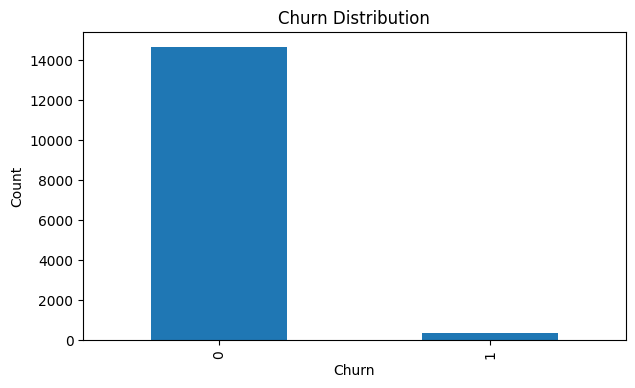

In [22]:
# =============================
# Cell 22: Plot Churn Distribution
# =============================
plt.figure(figsize=(7, 4))
df["churn"].value_counts().sort_index().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

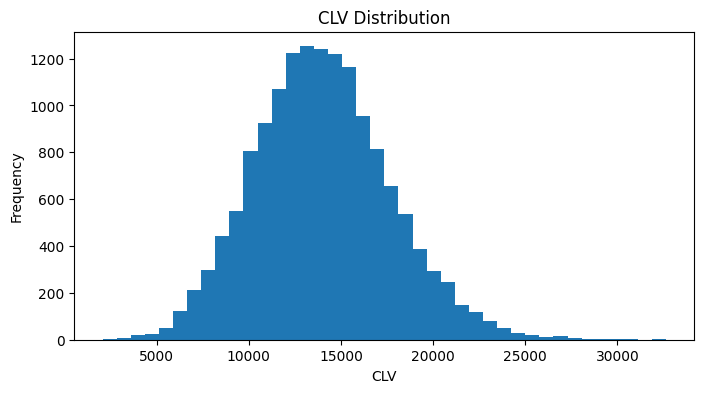

In [23]:
# =============================
# Cell 23: CLV Distribution
# =============================
plt.figure(figsize=(8, 4))
plt.hist(df["clv"], bins=40)
plt.title("CLV Distribution")
plt.xlabel("CLV")
plt.ylabel("Frequency")
plt.show()

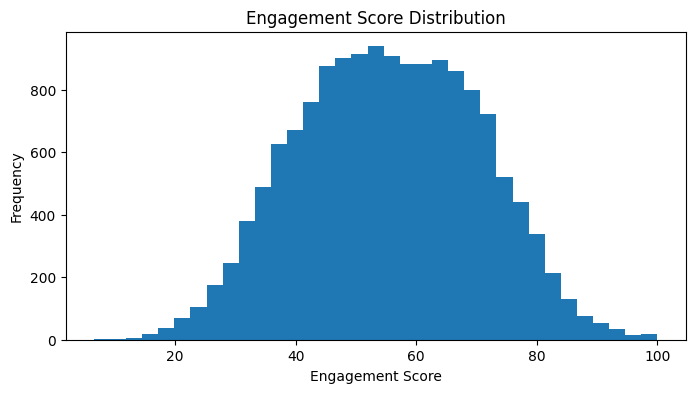

In [24]:
# =============================
# Cell 24: Engagement Distribution
# =============================
plt.figure(figsize=(8, 4))
plt.hist(df["engagement_score"], bins=35)
plt.title("Engagement Score Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Frequency")
plt.show()

In [25]:
# =============================
# Cell 25: Average Targets by Plan Type
# =============================
df.groupby("plan_type")[["churn", "clv", "engagement_score"]].mean().sort_values("clv", ascending=False)

,churn,clv,engagement_score
plan_type,,,
Enterprise,0.011511,16051.708926,58.024582
Premium,0.014634,14844.823131,56.707747
Standard,0.015669,13887.107326,54.870060
Basic,0.034193,13056.178580,54.595600


In [26]:
# =============================
# Cell 26: Average Targets by Segment
# =============================
df.groupby("segment")[["churn", "clv", "engagement_score"]].mean().sort_values("engagement_score", ascending=False)

,churn,clv,engagement_score
segment,,,
HighValue,0.014993,15556.873450,56.809180
Loyal,0.018852,14578.033577,55.574746
Growth,0.021038,13721.773346,55.217449
Budget,0.028333,12906.743468,54.829798


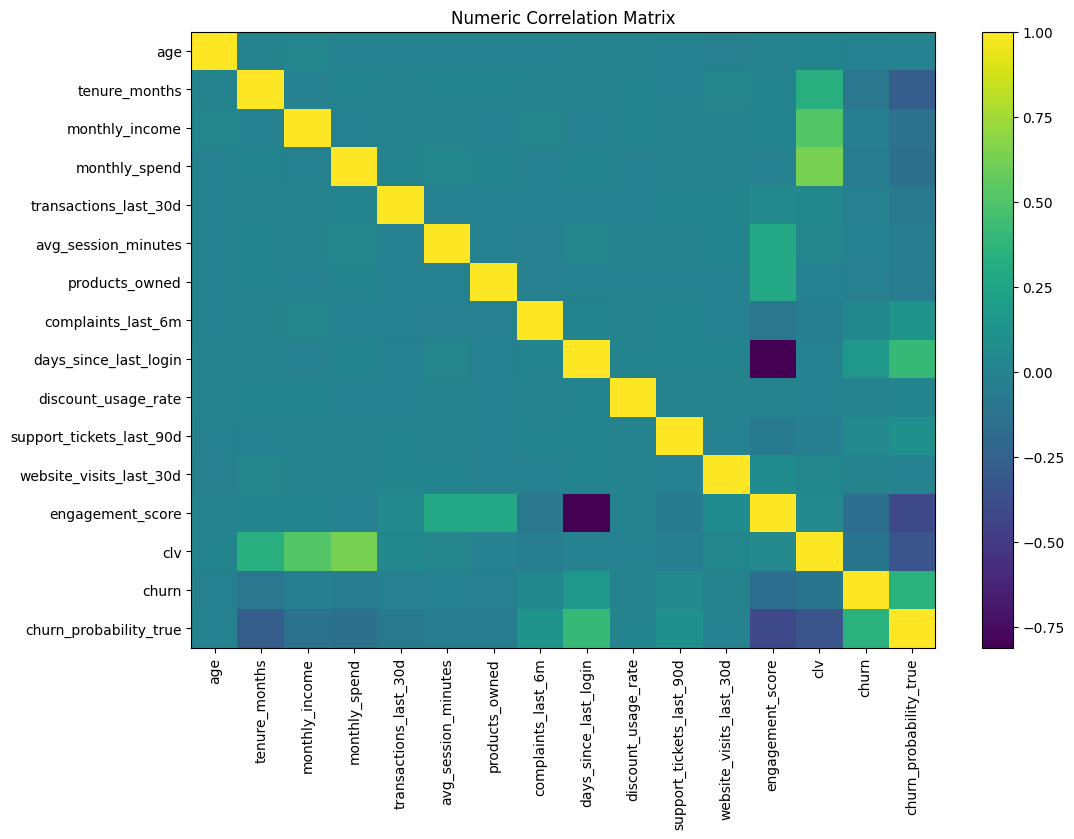

In [27]:
# =============================
# Cell 27: Correlation Matrix
# =============================
numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()

corr = df[numeric_cols_for_corr].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Numeric Correlation Matrix")
plt.colorbar()
plt.show()

## 6. Cohort / Segment View

This section adds a business-style cohort analysis before model building.

In [28]:
# =============================
# Cell 28: Create Simple Cohort Labels
# =============================
df["tenure_cohort"] = pd.cut(
    df["tenure_months"],
    bins=[0, 6, 12, 24, 48, 120],
    labels=["0-6", "7-12", "13-24", "25-48", "49+"]
)

df["spend_band"] = pd.qcut(
    df["monthly_spend"].fillna(df["monthly_spend"].median()),
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

df[["tenure_cohort", "spend_band"]].head()

,tenure_cohort,spend_band
0,13-24,Low
1,49+,High
2,49+,Low
3,25-48,High
4,49+,Mid-Low


In [29]:
# =============================
# Cell 29: Cohort Table
# =============================
cohort_table = df.groupby("tenure_cohort")[["churn", "clv", "engagement_score"]].mean()
cohort_table

,churn,clv,engagement_score
tenure_cohort,,,
0-6,0.048780,11896.315491,55.401111
7-12,0.039242,12199.903012,55.335143
13-24,0.040752,12565.515221,55.342532
25-48,0.030017,13128.621095,54.989789
49+,0.011826,14866.229591,55.662127


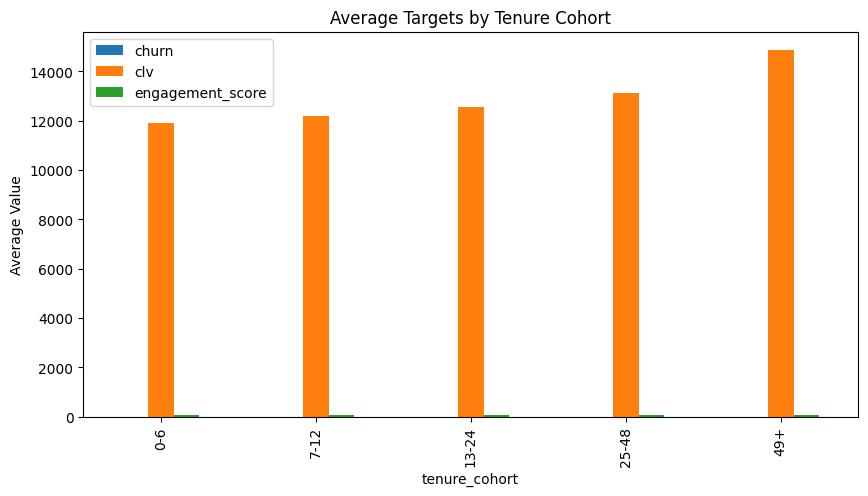

In [30]:
# =============================
# Cell 30: Cohort Visualization
# =============================
cohort_table.plot(kind="bar", figsize=(10, 5))
plt.title("Average Targets by Tenure Cohort")
plt.ylabel("Average Value")
plt.show()

## 7. Unsupervised Add-on: Customer Segmentation

This is not required for the ANN itself, but it improves the business story.

In [31]:
# =============================
# Cell 31: Features for Clustering
# =============================
cluster_features = df[
    [
        "tenure_months",
        "monthly_spend",
        "transactions_last_30d",
        "avg_session_minutes",
        "products_owned",
        "website_visits_last_30d",
        "engagement_score",
        "clv"
    ]
].copy()

cluster_features = cluster_features.fillna(cluster_features.median())
cluster_features.head()

,tenure_months,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,website_visits_last_30d,engagement_score,clv
0,15,162.430622,11,24.766641,2,13,50.190794,9073.516668
1,57,696.186063,9,30.480844,1,16,44.700944,13485.620322
2,58,20.000000,6,25.420407,3,13,66.694498,13534.159509
3,35,807.184387,8,17.365244,2,11,31.875375,14171.510782
4,88,368.285008,8,11.912645,6,15,71.888415,17533.970407


In [32]:
# =============================
# Cell 32: Scale Clustering Features
# =============================
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_features)
cluster_scaled[:3]

array([[-1.30530115, -1.455064  ,  1.058027  ,  0.08181313, -0.98918535,
        -0.26080184, -0.35197734, -1.33647015],
       [-0.094657  ,  1.55947109,  0.34797353,  0.66970607, -1.48990347,
         0.54265423, -0.71825603, -0.13969756],
       [-0.06583214, -2.25948129, -0.71710666,  0.14907442, -0.48846722,
        -0.26080184,  0.74913744, -0.12653142]])

In [33]:
# =============================
# Cell 33: KMeans Segmentation
# =============================
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
df["customer_segment_cluster"] = kmeans.fit_predict(cluster_scaled)
df["customer_segment_cluster"].value_counts().sort_index()

  File "C:\Users\atripathi\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\atripathi\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\atripathi\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\atripathi\AppData\Local\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


customer_segment_cluster
0    3650
1    3925
2    3646
3    3779
Name: count, dtype: int64

In [34]:
# =============================
# Cell 34: Segment Summary
# =============================
df.groupby("customer_segment_cluster")[["churn", "clv", "engagement_score", "monthly_spend"]].mean()

,churn,clv,engagement_score,monthly_spend
customer_segment_cluster,,,,
0,0.001644,15273.208828,65.437316,418.893466
1,0.046624,11953.680019,43.033476,314.776825
2,0.011245,17736.597140,50.843093,609.818505
3,0.025139,11293.078548,63.209282,345.566425


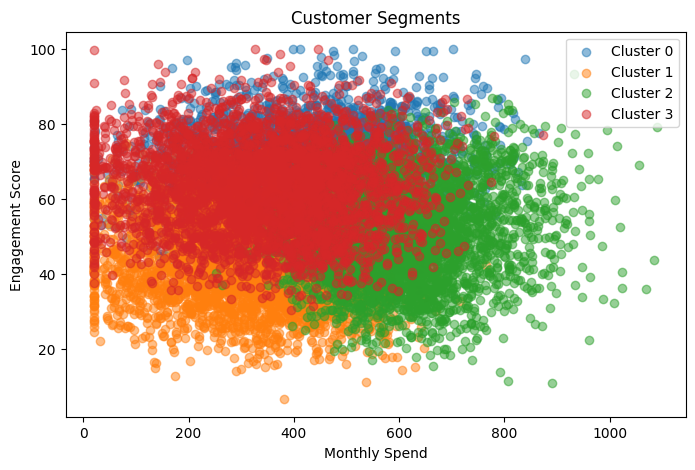

In [35]:
# =============================
# Cell 35: Segment Scatter Plot
# =============================
plt.figure(figsize=(8, 5))
for cluster_id in sorted(df["customer_segment_cluster"].unique()):
    subset = df[df["customer_segment_cluster"] == cluster_id]
    plt.scatter(
        subset["monthly_spend"],
        subset["engagement_score"],
        label=f"Cluster {cluster_id}",
        alpha=0.5
    )
plt.xlabel("Monthly Spend")
plt.ylabel("Engagement Score")
plt.title("Customer Segments")
plt.legend()
plt.show()

## 8. Feature and Target Definition

In [36]:
# =============================
# Cell 36: Define Inputs and Targets
# =============================
feature_columns = [
    "age",
    "tenure_months",
    "monthly_income",
    "monthly_spend",
    "transactions_last_30d",
    "avg_session_minutes",
    "products_owned",
    "complaints_last_6m",
    "days_since_last_login",
    "discount_usage_rate",
    "support_tickets_last_90d",
    "website_visits_last_30d",
    "region",
    "channel",
    "plan_type",
    "segment",
    "device_type",
    "customer_segment_cluster",
    "tenure_cohort",
    "spend_band"
]

target_churn = "churn"
target_clv = "clv"
target_engagement = "engagement_score"

In [37]:
# =============================
# Cell 37: Create Feature Matrix
# =============================
X = df[feature_columns].copy()
y_churn = df[target_churn].astype("float32").values
y_clv = df[target_clv].astype("float32").values
y_engagement = df[target_engagement].astype("float32").values

print(X.shape, y_churn.shape, y_clv.shape, y_engagement.shape)

(15000, 20) (15000,) (15000,) (15000,)


In [38]:
# =============================
# Cell 38: Identify Column Types
# =============================
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'tenure_months', 'monthly_income', 'monthly_spend', 'transactions_last_30d', 'avg_session_minutes', 'products_owned', 'complaints_last_6m', 'days_since_last_login', 'discount_usage_rate', 'support_tickets_last_90d', 'website_visits_last_30d', 'customer_segment_cluster']
Categorical features: ['region', 'channel', 'plan_type', 'segment', 'device_type', 'tenure_cohort', 'spend_band']


## 9. Train / Validation / Test Split

In [39]:
# =============================
# Cell 39: Primary Train/Test Split
# =============================
X_train_full, X_test, y_churn_train_full, y_churn_test, y_clv_train_full, y_clv_test, y_eng_train_full, y_eng_test = train_test_split(
    X,
    y_churn,
    y_clv,
    y_engagement,
    test_size=0.20,
    random_state=SEED,
    stratify=y_churn
)

print("Train full:", X_train_full.shape)
print("Test:", X_test.shape)

Train full: (12000, 20)
Test: (3000, 20)


In [40]:
# =============================
# Cell 40: Train/Validation Split
# =============================
X_train, X_val, y_churn_train, y_churn_val, y_clv_train, y_clv_val, y_eng_train, y_eng_val = train_test_split(
    X_train_full,
    y_churn_train_full,
    y_clv_train_full,
    y_eng_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_churn_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (9600, 20)
Validation: (2400, 20)
Test: (3000, 20)


## 10. Preprocessing

The project request mentioned **tokenization + preprocessing**.

For tabular ANN projects, there is **no text tokenization**.
The equivalent step is:
- numeric imputation
- categorical imputation
- one-hot encoding
- scaling

In [41]:
# =============================
# Cell 41: Numeric Transformer
# =============================
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

numeric_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

In [42]:
# =============================
# Cell 42: Categorical Transformer
# =============================
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

categorical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation.

In [43]:
# =============================
# Cell 43: Column Transformer
# =============================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [44]:
# =============================
# Cell 44: Fit Preprocessor
# =============================
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Train processed shape:", X_train_processed.shape)
print("Val processed shape:", X_val_processed.shape)
print("Test processed shape:", X_test_processed.shape)

Train processed shape: (9600, 43)
Val processed shape: (2400, 43)
Test processed shape: (3000, 43)


In [45]:
# =============================
# Cell 45: Convert to Dense Arrays
# =============================
X_train_nn = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_val_nn = X_val_processed.toarray() if hasattr(X_val_processed, "toarray") else X_val_processed
X_test_nn = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

print(X_train_nn.shape, X_val_nn.shape, X_test_nn.shape)

(9600, 43) (2400, 43) (3000, 43)


In [46]:
# =============================
# Cell 46: Regression Target Scaling
# =============================
clv_mean, clv_std = y_clv_train.mean(), y_clv_train.std()
eng_mean, eng_std = y_eng_train.mean(), y_eng_train.std()

y_clv_train_scaled = (y_clv_train - clv_mean) / clv_std
y_clv_val_scaled = (y_clv_val - clv_mean) / clv_std
y_clv_test_scaled = (y_clv_test - clv_mean) / clv_std

y_eng_train_scaled = (y_eng_train - eng_mean) / eng_std
y_eng_val_scaled = (y_eng_val - eng_mean) / eng_std
y_eng_test_scaled = (y_eng_test - eng_mean) / eng_std

print("Target scaling completed.")

Target scaling completed.


In [47]:
# =============================
# Cell 47: Class Imbalance Weights
# =============================
class_counts = pd.Series(y_churn_train).value_counts().sort_index()
total_count = class_counts.sum()

class_weight = {
    0: total_count / (2 * class_counts[0]),
    1: total_count / (2 * class_counts[1])
}

class_counts, class_weight

(0.0    9392
 1.0     208
 Name: count, dtype: int64,
 {0: 0.5110732538330494, 1: 23.076923076923077})

## 11. Multi-Head ANN Design

We use:
- shared trunk layers for common representation learning
- one head for churn classification
- one head for CLV regression
- one head for engagement regression

In [48]:
# =============================
# Cell 48: Input Dimension
# =============================
input_dim = X_train_nn.shape[1]
input_dim

43

In [49]:
# =============================
# Cell 49: Build Multi-Head ANN
# =============================
inputs = layers.Input(shape=(input_dim,), name="customer_features")

x = layers.Dense(256, activation="relu", name="shared_dense_1")(inputs)
x = layers.BatchNormalization(name="shared_bn_1")(x)
x = layers.Dropout(0.30, name="shared_dropout_1")(x)

x = layers.Dense(128, activation="relu", name="shared_dense_2")(x)
x = layers.BatchNormalization(name="shared_bn_2")(x)
x = layers.Dropout(0.25, name="shared_dropout_2")(x)

shared_repr = layers.Dense(64, activation="relu", name="shared_repr")(x)

churn_branch = layers.Dense(32, activation="relu", name="churn_dense_1")(shared_repr)
churn_branch = layers.Dropout(0.20, name="churn_dropout_1")(churn_branch)
churn_output = layers.Dense(1, activation="sigmoid", name="churn_output")(churn_branch)

clv_branch = layers.Dense(32, activation="relu", name="clv_dense_1")(shared_repr)
clv_branch = layers.Dropout(0.15, name="clv_dropout_1")(clv_branch)
clv_output = layers.Dense(1, activation="linear", name="clv_output")(clv_branch)

eng_branch = layers.Dense(32, activation="relu", name="eng_dense_1")(shared_repr)
eng_branch = layers.Dropout(0.15, name="eng_dropout_1")(eng_branch)
engagement_output = layers.Dense(1, activation="linear", name="engagement_output")(eng_branch)

model = Model(
    inputs=inputs,
    outputs=[churn_output, clv_output, engagement_output],
    name="multi_output_prediction_ann"
)

model.summary()

Model: "multi_output_prediction_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ customer_features             │ (None, 43)                │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dense_1 (Dense)        │ (None, 256)               │          11,264 │ customer_features[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_bn_1                   │ (None, 256)               │           1,024 │ shared_dense_1[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dropout_1 (Dropout)    │ (None, 256)               │               0 │ shared_bn_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dense_2 (Dense)        │ (None, 128)               │          32,896 │ shared_dropout_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_bn_2                   │ (None, 128)               │             512 │ shared_dense_2[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dropout_2 (Dropout)    │ (None, 128)               │               0 │ shared_bn_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_repr (Dense)           │ (None, 64)                │           8,256 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ churn_dense_1 (Dense)         │ (None, 32)                │           2,080 │ shared_repr[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ clv_dense_1 (Dense)           │ (None, 32)                │           2,080 │ shared_repr[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ eng_dense_1 (Dense)           │ (None, 32)                │           2,080 │ shared_repr[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ churn_dropout_1 (Dropout)     │ (None, 32)                │               0 │ churn_dense_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ clv_dropout_1 (Dropout)       │ (None, 32)                │               0 │ clv_dense_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ eng_dropout_1 (Dropout)       │ (None, 32)                │               0 │ eng_dense_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ churn_output (Dense)          │ (None, 1)                 │              33 │ churn_dropout_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ clv_output (Dense)            │ (None, 1)                 │              3

 Total params: 60,291 (235.51 KB)

 Trainable params: 59,523 (232.51 KB)

 Non-trainable params: 768 (3.00 KB)

In [50]:
# =============================
# Cell 50: Loss Weights
# =============================
loss_weights = {
    "churn_output": 1.2,
    "clv_output": 0.8,
    "engagement_output": 0.8
}

loss_weights

{'churn_output': 1.2, 'clv_output': 0.8, 'engagement_output': 0.8}

In [51]:
# =============================
# Cell 51: Compile Model
# =============================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "churn_output": "binary_crossentropy",
        "clv_output": "mse",
        "engagement_output": "mse"
    },
    loss_weights=loss_weights,
    metrics={
        "churn_output": [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc")
        ],
        "clv_output": [
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ],
        "engagement_output": [
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ]
    }
)

In [52]:
# =============================
# Cell 52: Save Model Diagram
# =============================
diagram_path = ARTIFACTS_DIR / "multi_output_ann_architecture.png"

try:
    plot_model(
        model,
        to_file=str(diagram_path),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=False,
        dpi=120
    )
    print("Diagram saved to:", diagram_path)
except Exception as e:
    print("plot_model could not save diagram in this environment.")
    print("Reason:", e)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Diagram saved to: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Multi-Output Prediction System\multi_output_ann_artifacts\multi_output_ann_architecture.png


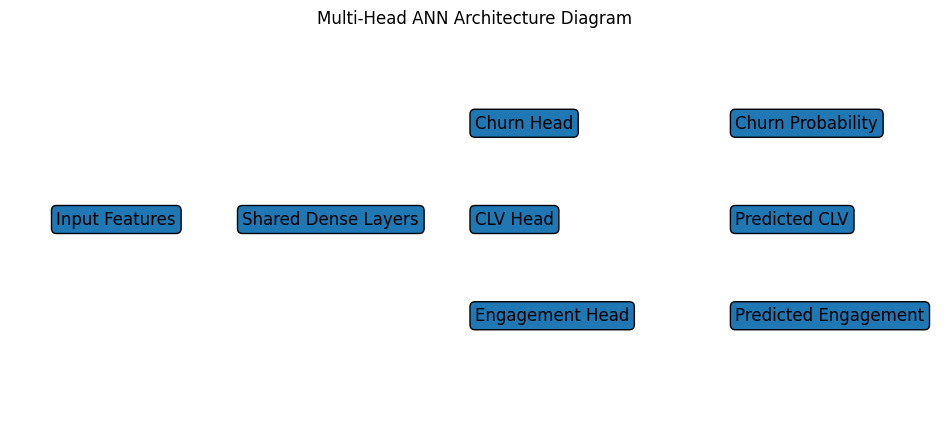

In [53]:
# =============================
# Cell 53: Manual Architecture Diagram (Always Works)
# =============================
plt.figure(figsize=(12, 5))
plt.text(0.05, 0.5, "Input Features", fontsize=12, bbox=dict(boxstyle="round"))
plt.text(0.25, 0.5, "Shared Dense Layers", fontsize=12, bbox=dict(boxstyle="round"))
plt.text(0.50, 0.75, "Churn Head", fontsize=12, bbox=dict(boxstyle="round"))
plt.text(0.50, 0.50, "CLV Head", fontsize=12, bbox=dict(boxstyle="round"))
plt.text(0.50, 0.25, "Engagement Head", fontsize=12, bbox=dict(boxstyle="round"))
plt.text(0.78, 0.75, "Churn Probability", fontsize=12, bbox=dict(boxstyle="round"))
plt.text(0.78, 0.50, "Predicted CLV", fontsize=12, bbox=dict(boxstyle="round"))
plt.text(0.78, 0.25, "Predicted Engagement", fontsize=12, bbox=dict(boxstyle="round"))
plt.axis("off")
plt.title("Multi-Head ANN Architecture Diagram")
plt.show()

In [54]:
# =============================
# Cell 54: Training Callbacks
# =============================
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5
    )
]

callbacks

In [55]:
# =============================
# Cell 55: Prepare Sample Weights
# =============================
sample_weights_churn = np.where(y_churn_train == 1, class_weight[1], class_weight[0]).astype("float32")
sample_weights_clv = np.ones_like(y_clv_train_scaled, dtype="float32")
sample_weights_eng = np.ones_like(y_eng_train_scaled, dtype="float32")

# Keras multi-output training is most stable when targets and sample weights
# are passed in the same order as model.outputs.
sample_weight_list = [
    sample_weights_churn,
    sample_weights_clv,
    sample_weights_eng
]

print("Sample weight lists prepared.")


Sample weight lists prepared.


In [56]:
# =============================
# Cell 56: Train Model
# =============================
# Pass targets and sample weights as lists in the same order as:
# [churn_output, clv_output, engagement_output]
history = model.fit(
    X_train_nn,
    [
        y_churn_train,
        y_clv_train_scaled,
        y_eng_train_scaled
    ],
    validation_data=(
        X_val_nn,
        [
            y_churn_val,
            y_clv_val_scaled,
            y_eng_val_scaled
        ]
    ),
    epochs=40,
    batch_size=128,
    verbose=1,
    callbacks=callbacks,
    sample_weight=sample_weight_list
)


Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - churn_output_accuracy: 0.6288 - churn_output_auc: 0.7216 - churn_output_loss: 0.6167 - clv_output_loss: 0.6134 - clv_output_mae: 0.6054 - engagement_output_loss: 0.6788 - engagement_output_mae: 0.6400 - loss: 1.7737 - val_churn_output_accuracy: 0.7242 - val_churn_output_auc: 0.8743 - val_churn_output_loss: 0.5753 - val_clv_output_loss: 0.6444 - val_clv_output_mae: 0.6330 - val_engagement_output_loss: 0.7449 - val_engagement_output_mae: 0.7092 - val_loss: 1.8012 - learning_rate: 0.0010
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - churn_output_accuracy: 0.7161 - churn_output_auc: 0.8289 - churn_output_loss: 0.5157 - clv_output_loss: 0.3271 - clv_output_mae: 0.4478 - engagement_output_loss: 0.3742 - engagement_output_mae: 0.4858 - loss: 1.1799 - val_churn_output_accuracy: 0.7496 - val_churn_output_auc: 0.9002 - val_churn_output_loss: 0.5053 - val_clv_output_loss: 0.4351 - val_clv_output_mae: 0.5173 - val_engagement_output_loss: 0.

In [57]:
# =============================
# Cell 57: Training History Keys
# =============================
history.history.keys()

dict_keys(['churn_output_accuracy', 'churn_output_auc', 'churn_output_loss', 'clv_output_loss', 'clv_output_mae', 'engagement_output_loss', 'engagement_output_mae', 'loss', 'val_churn_output_accuracy', 'val_churn_output_auc', 'val_churn_output_loss', 'val_clv_output_loss', 'val_clv_output_mae', 'val_engagement_output_loss', 'val_engagement_output_mae', 'val_loss', 'learning_rate'])

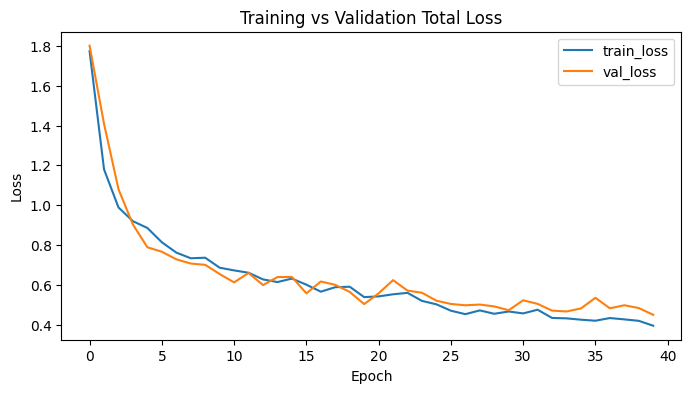

In [58]:
# =============================
# Cell 58: Plot Total Loss
# =============================
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

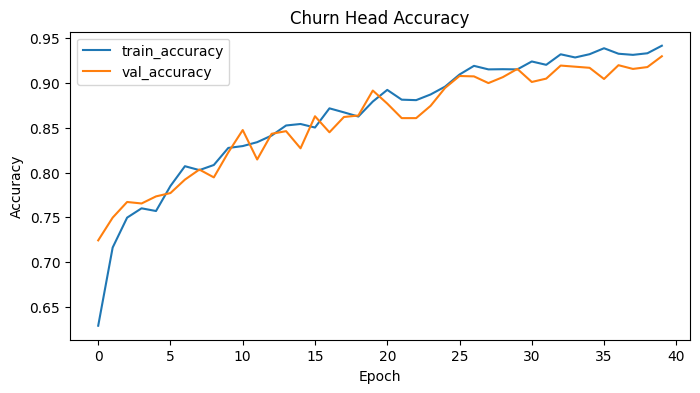

In [59]:
# =============================
# Cell 59: Plot Churn Accuracy
# =============================
plt.figure(figsize=(8, 4))
plt.plot(history.history["churn_output_accuracy"], label="train_accuracy")
plt.plot(history.history["val_churn_output_accuracy"], label="val_accuracy")
plt.title("Churn Head Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

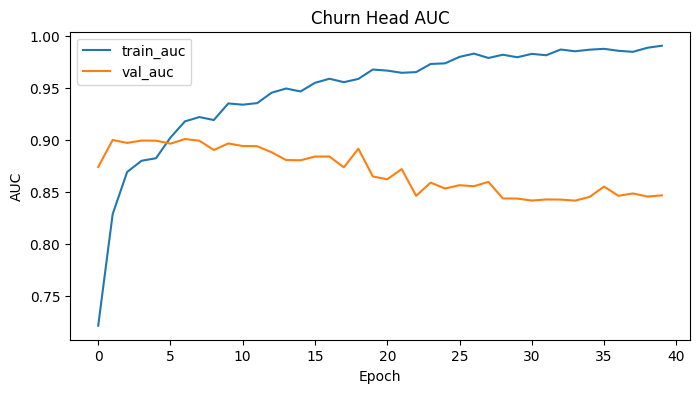

In [60]:
# =============================
# Cell 60: Plot Churn AUC
# =============================
plt.figure(figsize=(8, 4))
plt.plot(history.history["churn_output_auc"], label="train_auc")
plt.plot(history.history["val_churn_output_auc"], label="val_auc")
plt.title("Churn Head AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

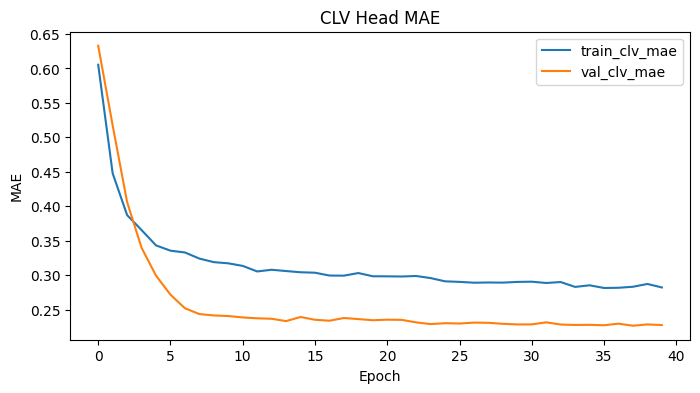

In [61]:
# =============================
# Cell 61: Plot CLV MAE
# =============================
plt.figure(figsize=(8, 4))
plt.plot(history.history["clv_output_mae"], label="train_clv_mae")
plt.plot(history.history["val_clv_output_mae"], label="val_clv_mae")
plt.title("CLV Head MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

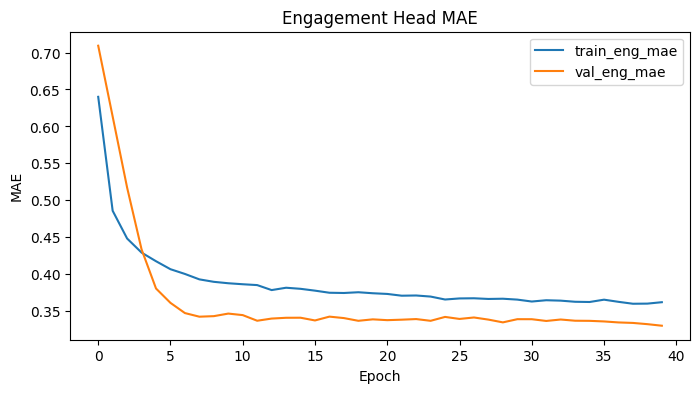

In [62]:
# =============================
# Cell 62: Plot Engagement MAE
# =============================
plt.figure(figsize=(8, 4))
plt.plot(history.history["engagement_output_mae"], label="train_eng_mae")
plt.plot(history.history["val_engagement_output_mae"], label="val_eng_mae")
plt.title("Engagement Head MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

## 12. Inference on Test Set

In [63]:
# =============================
# Cell 63: Generate Predictions
# =============================
pred_churn_proba, pred_clv_scaled, pred_eng_scaled = model.predict(X_test_nn, verbose=0)

pred_churn_proba = pred_churn_proba.ravel()
pred_clv_scaled = pred_clv_scaled.ravel()
pred_eng_scaled = pred_eng_scaled.ravel()

pred_clv = pred_clv_scaled * clv_std + clv_mean
pred_engagement = pred_eng_scaled * eng_std + eng_mean

pred_churn = (pred_churn_proba >= 0.50).astype(int)

print("Predictions generated.")

Predictions generated.


In [64]:
# =============================
# Cell 64: Classification Metrics
# =============================
churn_accuracy = accuracy_score(y_churn_test, pred_churn)
churn_precision = precision_score(y_churn_test, pred_churn)
churn_recall = recall_score(y_churn_test, pred_churn)
churn_f1 = f1_score(y_churn_test, pred_churn)
churn_auc = roc_auc_score(y_churn_test, pred_churn_proba)

print("Accuracy :", round(churn_accuracy, 4))
print("Precision:", round(churn_precision, 4))
print("Recall   :", round(churn_recall, 4))
print("F1 Score :", round(churn_f1, 4))
print("ROC-AUC  :", round(churn_auc, 4))

Accuracy : 0.929
Precision: 0.1105
Recall   : 0.3231
F1 Score : 0.1647
ROC-AUC  : 0.8167


In [65]:
# =============================
# Cell 65: CLV Regression Metrics
# =============================
clv_mae = mean_absolute_error(y_clv_test, pred_clv)
clv_rmse = np.sqrt(mean_squared_error(y_clv_test, pred_clv))
clv_r2 = r2_score(y_clv_test, pred_clv)
clv_mape = np.mean(np.abs((y_clv_test - pred_clv) / np.maximum(y_clv_test, 1))) * 100

print("CLV MAE :", round(clv_mae, 4))
print("CLV RMSE:", round(clv_rmse, 4))
print("CLV R2  :", round(clv_r2, 4))
print("CLV MAPE:", round(clv_mape, 4))

CLV MAE : 859.1419
CLV RMSE: 1113.2748
CLV R2  : 0.9101
CLV MAPE: 6.8943


In [66]:
# =============================
# Cell 66: Engagement Regression Metrics
# =============================
eng_mae = mean_absolute_error(y_eng_test, pred_engagement)
eng_rmse = np.sqrt(mean_squared_error(y_eng_test, pred_engagement))
eng_r2 = r2_score(y_eng_test, pred_engagement)
eng_mape = np.mean(np.abs((y_eng_test - pred_engagement) / np.maximum(y_eng_test, 1))) * 100

print("Engagement MAE :", round(eng_mae, 4))
print("Engagement RMSE:", round(eng_rmse, 4))
print("Engagement R2  :", round(eng_r2, 4))
print("Engagement MAPE:", round(eng_mape, 4))

Engagement MAE : 4.9144
Engagement RMSE: 6.211
Engagement R2  : 0.8319
Engagement MAPE: 9.9623


In [67]:
# =============================
# Cell 67: Classification Report
# =============================
print(classification_report(y_churn_test, pred_churn, digits=4))

              precision    recall  f1-score   support

         0.0     0.9843    0.9424    0.9629      2935
         1.0     0.1105    0.3231    0.1647        65

    accuracy                         0.9290      3000
   macro avg     0.5474    0.6327    0.5638      3000
weighted avg     0.9654    0.9290    0.9456      3000



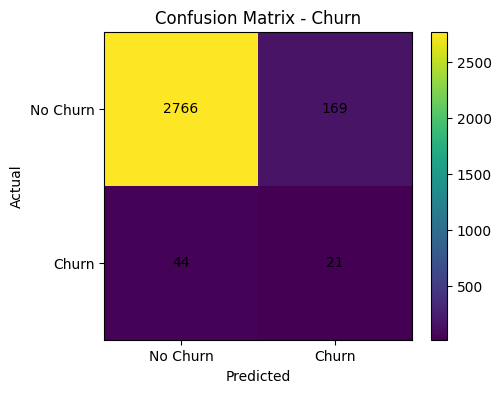

In [68]:
# =============================
# Cell 68: Confusion Matrix
# =============================
cm = confusion_matrix(y_churn_test, pred_churn)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Churn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

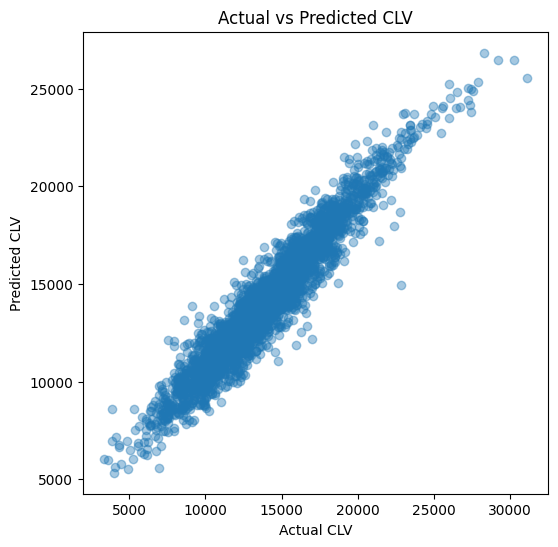

In [69]:
# =============================
# Cell 69: Actual vs Predicted CLV
# =============================
plt.figure(figsize=(6, 6))
plt.scatter(y_clv_test, pred_clv, alpha=0.4)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")
plt.show()

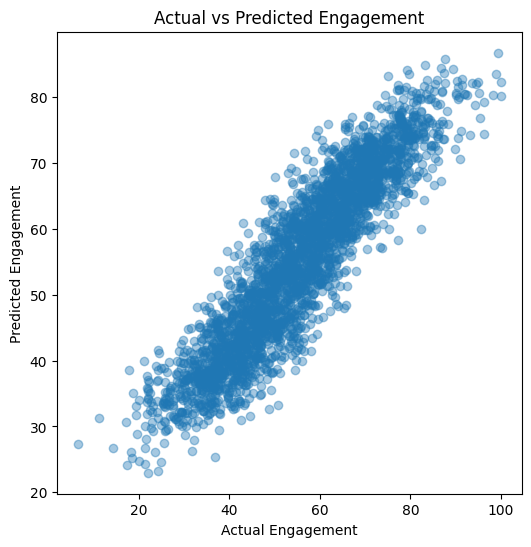

In [70]:
# =============================
# Cell 70: Actual vs Predicted Engagement
# =============================
plt.figure(figsize=(6, 6))
plt.scatter(y_eng_test, pred_engagement, alpha=0.4)
plt.xlabel("Actual Engagement")
plt.ylabel("Predicted Engagement")
plt.title("Actual vs Predicted Engagement")
plt.show()

## 13. Multi-Output Sample Outputs

In [71]:
# =============================
# Cell 71: Create Prediction Results Table
# =============================
results_df = X_test.reset_index(drop=True).copy()

results_df["actual_churn"] = y_churn_test
results_df["predicted_churn"] = pred_churn
results_df["predicted_churn_probability"] = pred_churn_proba

results_df["actual_clv"] = y_clv_test
results_df["predicted_clv"] = pred_clv

results_df["actual_engagement"] = y_eng_test
results_df["predicted_engagement"] = pred_engagement

results_df.head()

,age,tenure_months,monthly_income,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,complaints_last_6m,days_since_last_login,discount_usage_rate,...,customer_segment_cluster,tenure_cohort,spend_band,actual_churn,predicted_churn,predicted_churn_probability,actual_clv,predicted_clv,actual_engagement,predicted_engagement
0,33,98,3297.958354,470.789473,12,17.085549,1,2,46,0.329011,...,1,49+,Mid-High,0.0,0,1.141958e-04,13719.235352,13597.428711,41.669346,49.422161
1,74,58,6087.540728,153.301459,6,11.394939,6,1,47,0.295520,...,1,49+,Low,0.0,0,2.988801e-05,10301.220703,12138.013672,57.870564,57.823906
2,40,114,6032.703668,542.422892,8,20.528260,6,0,99,0.139456,...,0,49+,High,0.0,0,8.693701e-09,18213.894531,18718.089844,49.623325,49.381340
3,74,119,6188.349765,234.809484,6,18.458305,4,0,98,0.284681,...,1,49+,Low,0.0,0,1.744081e-02,14116.625000,13436.906250,43.535480,38.399330
4,34,62,8713.729644,644.101629,10,21.067646,4,1,44,0.326524,...,2,49+,High,0.0,0,1.013662e-04,17606.187500,17506.660156,56.692791,59.838039


In [72]:
# =============================
# Cell 72: Add Risk / Value Buckets
# =============================
results_df["churn_risk_bucket"] = pd.cut(
    results_df["predicted_churn_probability"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

results_df["clv_bucket"] = pd.qcut(
    results_df["predicted_clv"],
    q=3,
    labels=["LowValue", "MidValue", "HighValue"]
)

results_df["engagement_bucket"] = pd.qcut(
    results_df["predicted_engagement"],
    q=3,
    labels=["LowEngagement", "MidEngagement", "HighEngagement"]
)

results_df.head()

,age,tenure_months,monthly_income,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,complaints_last_6m,days_since_last_login,discount_usage_rate,...,actual_churn,predicted_churn,predicted_churn_probability,actual_clv,predicted_clv,actual_engagement,predicted_engagement,churn_risk_bucket,clv_bucket,engagement_bucket
0,33,98,3297.958354,470.789473,12,17.085549,1,2,46,0.329011,...,0.0,0,1.141958e-04,13719.235352,13597.428711,41.669346,49.422161,Low,MidValue,MidEngagement
1,74,58,6087.540728,153.301459,6,11.394939,6,1,47,0.295520,...,0.0,0,2.988801e-05,10301.220703,12138.013672,57.870564,57.823906,Low,LowValue,MidEngagement
2,40,114,6032.703668,542.422892,8,20.528260,6,0,99,0.139456,...,0.0,0,8.693701e-09,18213.894531,18718.089844,49.623325,49.381340,Low,HighValue,MidEngagement
3,74,119,6188.349765,234.809484,6,18.458305,4,0,98,0.284681,...,0.0,0,1.744081e-02,14116.625000,13436.906250,43.535480,38.399330,Low,MidValue,LowEngagement
4,34,62,8713.729644,644.101629,10,21.067646,4,1,44,0.326524,...,0.0,0,1.013662e-04,17606.187500,17506.660156,56.692791,59.838039,Low,HighValue,MidEngagement


In [73]:
# =============================
# Cell 73: Sample Outputs
# =============================
results_df[
    [
        "plan_type",
        "segment",
        "actual_churn",
        "predicted_churn",
        "predicted_churn_probability",
        "actual_clv",
        "predicted_clv",
        "actual_engagement",
        "predicted_engagement",
        "churn_risk_bucket",
        "clv_bucket",
        "engagement_bucket"
    ]
].head(15)

,plan_type,segment,actual_churn,predicted_churn,predicted_churn_probability,actual_clv,predicted_clv,actual_engagement,predicted_engagement,churn_risk_bucket,clv_bucket,engagement_bucket
0,Standard,Loyal,0.0,0,1.141958e-04,13719.235352,13597.428711,41.669346,49.422161,Low,MidValue,MidEngagement
1,Premium,HighValue,0.0,0,2.988801e-05,10301.220703,12138.013672,57.870564,57.823906,Low,LowValue,MidEngagement
2,Standard,HighValue,0.0,0,8.693701e-09,18213.894531,18718.089844,49.623325,49.381340,Low,HighValue,MidEngagement
3,Premium,Growth,0.0,0,1.744081e-02,14116.625000,13436.906250,43.535480,38.399330,Low,MidValue,LowEngagement
4,Standard,Budget,0.0,0,1.013662e-04,17606.187500,17506.660156,56.692791,59.838039,Low,HighValue,MidEngagement
5,Basic,HighValue,0.0,0,1.246529e-05,17762.582031,17866.904297,41.500263,42.059624,Low,HighValue,LowEngagement
6,Basic,Loyal,0.0,0,1.605877e-09,14909.639648,15930.535156,56.784264,71.876312,Low,HighValue,HighEngagement
7,Premium,Loyal,1.0,1,6.765125e-01,10666.275391,11968.546875,46.202366,52.833378,High,LowValue,MidEngagement
8,Standard,HighValue,0.0,0,7.293824e-05,16783.384766,16641.115234,46.655945,48.677773,Low,HighValue,MidEngagement
9,Basic,Budget,0.0,0,3.918404e-02,12718.922852,11911.235352,61.953751,59.176163,Low,LowValue,MidEngagement


## 14. Error Analysis

In [74]:
# =============================
# Cell 74: Churn Misclassifications
# =============================
misclassified = results_df[results_df["actual_churn"] != results_df["predicted_churn"]].copy()
print("Misclassified churn cases:", len(misclassified))
misclassified.head()

Misclassified churn cases: 213


,age,tenure_months,monthly_income,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,complaints_last_6m,days_since_last_login,discount_usage_rate,...,actual_churn,predicted_churn,predicted_churn_probability,actual_clv,predicted_clv,actual_engagement,predicted_engagement,churn_risk_bucket,clv_bucket,engagement_bucket
19,22,8,2323.241898,147.782903,7,20.324193,1,2,91,0.373111,...,0.0,1,0.825651,3627.694336,6006.793457,32.328289,36.859505,High,LowValue,LowEngagement
27,27,5,9088.602607,207.294039,9,30.241306,3,0,53,0.396212,...,0.0,1,0.670804,8821.924805,10402.586914,49.556976,55.988850,High,LowValue,MidEngagement
28,50,23,7721.186834,262.606555,13,27.149584,6,0,65,0.400732,...,0.0,1,0.628076,11975.019531,11300.109375,51.116280,60.444832,Medium,LowValue,MidEngagement
44,67,43,3864.002343,567.561070,5,11.214014,1,1,116,0.484039,...,0.0,1,0.994410,9559.632812,11029.649414,25.568222,27.414551,High,LowValue,LowEngagement
70,50,38,7584.124743,287.848419,5,20.044392,6,0,118,0.312169,...,0.0,1,0.710095,10561.029297,11780.398438,37.662670,35.810669,High,LowValue,LowEngagement


In [75]:
# =============================
# Cell 75: Largest CLV Errors
# =============================
results_df["clv_abs_error"] = np.abs(results_df["actual_clv"] - results_df["predicted_clv"])
results_df.sort_values("clv_abs_error", ascending=False).head(10)

,age,tenure_months,monthly_income,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,complaints_last_6m,days_since_last_login,discount_usage_rate,...,predicted_churn,predicted_churn_probability,actual_clv,predicted_clv,actual_engagement,predicted_engagement,churn_risk_bucket,clv_bucket,engagement_bucket,clv_abs_error
1011,64,31,8667.883997,NaN,7,27.987834,1,0,85,0.699186,...,0,4.705161e-01,22840.953125,14933.732422,24.438835,41.115391,Medium,MidValue,LowEngagement,7907.220703
946,61,46,8500.432273,812.256920,13,7.038289,7,1,96,0.347246,...,0,1.139455e-09,31114.910156,25513.695312,42.366188,50.964588,Low,HighValue,MidEngagement,5601.214844
439,40,22,NaN,437.208513,3,26.161385,2,1,63,0.208346,...,0,2.396555e-01,16978.546875,12181.190430,46.283634,45.753929,Low,LowValue,LowEngagement,4797.356445
1996,20,2,6389.002324,NaN,11,18.244528,3,1,59,0.739638,...,0,3.861755e-05,9106.984375,13848.324219,59.487209,56.792637,Low,MidValue,MidEngagement,4741.339844
690,45,13,NaN,151.936035,9,25.045298,3,1,51,0.402610,...,0,1.581666e-01,3888.733643,8592.675781,50.650604,57.298698,Low,LowValue,MidEngagement,4703.942383
1747,25,21,6535.164287,NaN,6,14.222354,4,1,105,0.096569,...,0,1.897669e-01,7513.759766,12128.463867,44.990280,37.472496,Low,LowValue,LowEngagement,4614.704102
185,52,57,6359.750172,NaN,8,2.210383,3,1,24,0.335996,...,0,9.414530e-06,8584.994141,13153.750977,53.615116,52.798347,Low,MidValue,MidEngagement,4568.756836
610,72,39,11820.382658,NaN,6,25.603174,7,2,101,0.387299,...,0,5.041887e-02,22354.636719,17947.296875,44.325806,44.477390,Low,HighValue,LowEngagement,4407.339844
2519,18,111,NaN,NaN,10,25.317068,4,1,117,0.536947,...,0,5.646753e-03,21385.332031,17169.375000,34.976200,38.038231,Low,HighValue,LowEngagement,4215.957031
904,69,95,NaN,169.918364,14,21.662992,3,0,4,0.326485,...,0,7.270148e-07,7911.855957,12079.019531,80.107483,74.170349,Low,LowValue,HighEngagement,4167.163574


In [76]:
# =============================
# Cell 76: Largest Engagement Errors
# =============================
results_df["eng_abs_error"] = np.abs(results_df["actual_engagement"] - results_df["predicted_engagement"])
results_df.sort_values("eng_abs_error", ascending=False).head(10)

,age,tenure_months,monthly_income,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,complaints_last_6m,days_since_last_login,discount_usage_rate,...,predicted_churn_probability,actual_clv,predicted_clv,actual_engagement,predicted_engagement,churn_risk_bucket,clv_bucket,engagement_bucket,clv_abs_error,eng_abs_error
1549,44,30,NaN,511.535813,5,16.951037,5,1,36,0.242966,...,2.274074e-03,10115.262695,12560.797852,82.447441,59.950008,Low,MidValue,MidEngagement,2445.535156,22.497433
2582,37,105,9507.181518,290.198617,12,9.673162,6,0,4,0.107312,...,1.782661e-02,15229.805664,15841.053711,96.258179,74.454590,Low,HighValue,HighEngagement,611.248047,21.803589
1237,42,86,4987.225618,585.827900,5,3.784631,1,1,55,0.260814,...,5.668662e-03,12701.669922,13686.240234,17.852957,38.599426,Low,MidValue,LowEngagement,984.570312,20.746469
1863,46,70,11004.834189,381.607525,5,8.742531,1,3,108,0.284862,...,1.542260e-02,18361.654297,17803.386719,6.512782,27.258421,Low,HighValue,LowEngagement,558.267578,20.745640
2207,67,49,4993.702036,341.728158,6,29.640364,6,1,20,0.319470,...,1.794553e-07,12555.225586,11448.069336,91.035141,70.563553,Low,LowValue,HighEngagement,1107.156250,20.471588
1040,32,46,4257.261186,537.412461,7,20.319211,4,2,113,0.739814,...,9.853714e-01,9310.771484,10553.897461,11.089403,31.212904,High,LowValue,LowEngagement,1243.125977,20.123501
457,51,65,7660.649855,512.209561,7,32.248009,7,0,8,0.176234,...,6.746082e-12,20038.388672,19643.574219,100.000000,80.239029,Low,HighValue,HighEngagement,394.814453,19.760971
2527,24,54,2121.743178,687.790149,11,13.747310,6,1,14,0.317746,...,1.064364e-05,9244.485352,11982.018555,86.693092,67.225372,Low,LowValue,HighEngagement,2737.533203,19.467720
328,23,64,4502.418167,468.469909,9,29.863884,7,3,19,0.691553,...,1.689915e-10,15867.020508,14505.682617,93.221947,74.337494,Low,MidValue,HighEngagement,1361.337891,18.884453
886,21,95,7558.520960,190.354885,8,19.071144,3,2,35,0.295098,...,1.366269e-07,13036.180664,13460.311523,77.222015,58.370827,Low,MidValue,MidEngagement,424.130859,18.851189


In [77]:
# =============================
# Cell 77: Error by Plan Type
# =============================
error_by_plan = results_df.groupby("plan_type")[["clv_abs_error", "eng_abs_error"]].mean()
error_by_plan

,clv_abs_error,eng_abs_error
plan_type,,
Basic,856.151611,4.624341
Enterprise,1002.570923,5.398944
Premium,858.089294,5.112547
Standard,824.929688,4.985098


In [78]:
# =============================
# Cell 78: Error by Segment
# =============================
error_by_segment = results_df.groupby("segment")[["clv_abs_error", "eng_abs_error"]].mean()
error_by_segment

,clv_abs_error,eng_abs_error
segment,,
Budget,844.330322,4.973906
Growth,828.998535,5.003115
HighValue,933.112793,4.840939
Loyal,863.609375,4.783475


In [79]:
# =============================
# Cell 79: Threshold Tuning for Churn
# =============================
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []
for threshold in thresholds:
    pred_tmp = (pred_churn_proba >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_churn_test, pred_tmp),
        "precision": precision_score(y_churn_test, pred_tmp, zero_division=0),
        "recall": recall_score(y_churn_test, pred_tmp, zero_division=0),
        "f1": f1_score(y_churn_test, pred_tmp, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,accuracy,precision,recall,f1
0,0.10,0.881333,0.092437,0.507692,0.156398
1,0.15,0.893000,0.094937,0.461538,0.157480
2,0.20,0.903667,0.105634,0.461538,0.171920
3,0.25,0.909667,0.112782,0.461538,0.181269
4,0.30,0.914333,0.112903,0.430769,0.178914
5,0.35,0.920000,0.107623,0.369231,0.166667
6,0.40,0.921667,0.106481,0.353846,0.163701
7,0.45,0.925667,0.108911,0.338462,0.164794
8,0.50,0.929000,0.110526,0.323077,0.164706
9,0.55,0.931333,0.114754,0.323077,0.169355


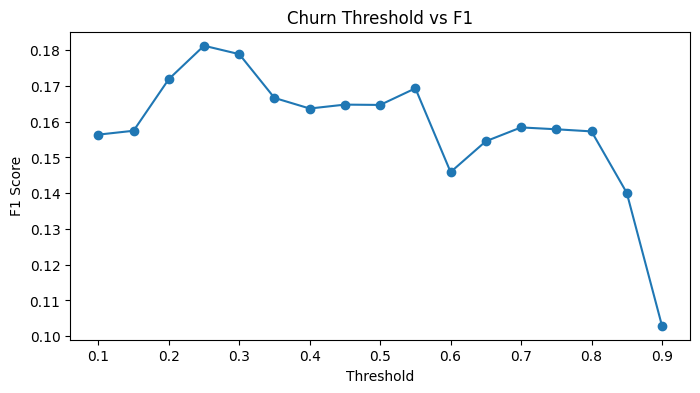

In [80]:
# =============================
# Cell 80: Plot Threshold vs F1
# =============================
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o")
plt.title("Churn Threshold vs F1")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()

## 15. Optional Add-on: Simple Explainability

This notebook uses a lightweight explainability approach by checking permutation-style feature importance with a simple drop-column approximation on the churn score.

In [81]:
# =============================
# Cell 81: Get Feature Names After Preprocessing
# =============================
feature_names_num = numeric_features
feature_names_cat = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features).tolist()

all_processed_feature_names = feature_names_num + feature_names_cat
len(all_processed_feature_names)

43

In [82]:
# =============================
# Cell 82: Lightweight Weight-Based Importance Proxy
# =============================
first_layer_weights = model.get_layer("shared_dense_1").get_weights()[0]
importance_proxy = np.mean(np.abs(first_layer_weights), axis=1)

importance_df = pd.DataFrame({
    "feature": all_processed_feature_names,
    "importance_proxy": importance_proxy
}).sort_values("importance_proxy", ascending=False)

importance_df.head(20)

,feature,importance_proxy
23,plan_type_Enterprise,0.108132
8,days_since_last_login,0.105032
28,segment_HighValue,0.094001
2,monthly_income,0.087081
3,monthly_spend,0.084139
25,plan_type_Standard,0.084095
38,tenure_cohort_7-12,0.083252
22,plan_type_Basic,0.083173
26,segment_Budget,0.083128
16,region_South,0.082004


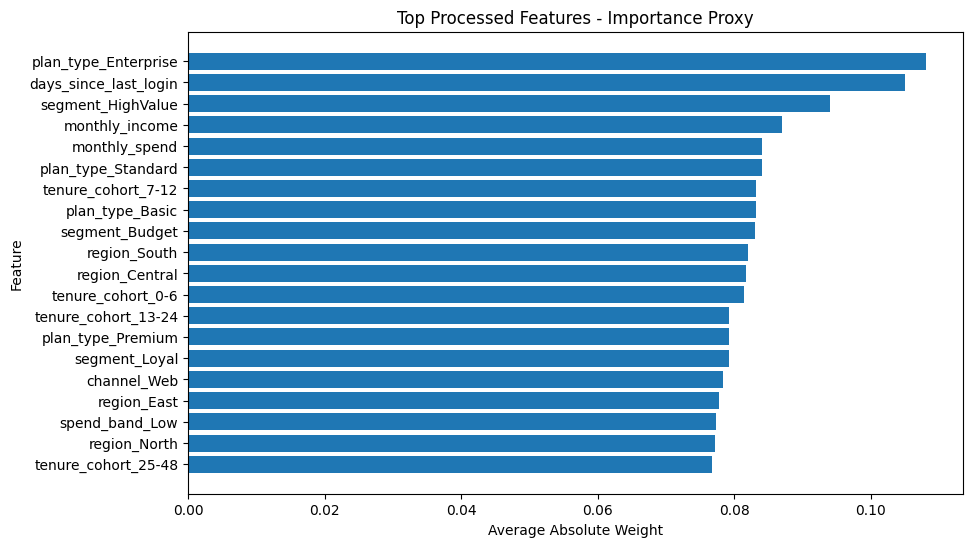

In [83]:
# =============================
# Cell 83: Plot Top Importance Proxy Features
# =============================
top_importance = importance_df.head(20).sort_values("importance_proxy")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"], top_importance["importance_proxy"])
plt.title("Top Processed Features - Importance Proxy")
plt.xlabel("Average Absolute Weight")
plt.ylabel("Feature")
plt.show()

## 16. Save Model and Artifacts

In [84]:
# =============================
# Cell 84: Save Model
# =============================
model.save(MODEL_PATH)
print("Model saved to:", MODEL_PATH)

Model saved to: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Multi-Output Prediction System\multi_output_ann_artifacts\multi_output_ann_model.keras


In [85]:
# =============================
# Cell 85: Save Results
# =============================
results_path = ARTIFACTS_DIR / "multi_output_predictions.csv"
results_df.to_csv(results_path, index=False)
print("Results saved to:", results_path)

Results saved to: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Multi-Output Prediction System\multi_output_ann_artifacts\multi_output_predictions.csv


## 17. Deployment Demo

The next cells simulate a mini deployment/inference pipeline.

In [86]:
# =============================
# Cell 86: Single Row Prediction Helper
# =============================
def predict_single_customer(input_df, fitted_preprocessor, trained_model, clv_mean, clv_std, eng_mean, eng_std, threshold=0.50):
    processed = fitted_preprocessor.transform(input_df)
    processed = processed.toarray() if hasattr(processed, "toarray") else processed

    churn_proba_pred, clv_scaled_pred, eng_scaled_pred = trained_model.predict(processed, verbose=0)

    churn_proba_pred = float(churn_proba_pred.ravel()[0])
    clv_pred = float(clv_scaled_pred.ravel()[0] * clv_std + clv_mean)
    eng_pred = float(eng_scaled_pred.ravel()[0] * eng_std + eng_mean)

    return {
        "predicted_churn_probability": churn_proba_pred,
        "predicted_churn_label": int(churn_proba_pred >= threshold),
        "predicted_clv": clv_pred,
        "predicted_engagement_score": eng_pred
    }

In [87]:
# =============================
# Cell 87: Demo Inference Input
# =============================
demo_customer = pd.DataFrame([{
    "age": 34,
    "tenure_months": 9,
    "monthly_income": 5200,
    "monthly_spend": 260,
    "transactions_last_30d": 4,
    "avg_session_minutes": 12,
    "products_owned": 2,
    "complaints_last_6m": 2,
    "days_since_last_login": 26,
    "discount_usage_rate": 0.42,
    "support_tickets_last_90d": 2,
    "website_visits_last_30d": 7,
    "region": "South",
    "channel": "Mobile",
    "plan_type": "Basic",
    "segment": "Budget",
    "device_type": "Android",
    "customer_segment_cluster": 0,
    "tenure_cohort": "7-12",
    "spend_band": "Mid-Low"
}])

demo_customer

,age,tenure_months,monthly_income,monthly_spend,transactions_last_30d,avg_session_minutes,products_owned,complaints_last_6m,days_since_last_login,discount_usage_rate,support_tickets_last_90d,website_visits_last_30d,region,channel,plan_type,segment,device_type,customer_segment_cluster,tenure_cohort,spend_band
0,34,9,5200,260,4,12,2,2,26,0.42,2,7,South,Mobile,Basic,Budget,Android,0,7-12,Mid-Low


In [88]:
# =============================
# Cell 88: Demo Prediction
# =============================
demo_prediction = predict_single_customer(
    input_df=demo_customer,
    fitted_preprocessor=preprocessor,
    trained_model=model,
    clv_mean=clv_mean,
    clv_std=clv_std,
    eng_mean=eng_mean,
    eng_std=eng_std,
    threshold=0.50
)

demo_prediction

{'predicted_churn_probability': 0.03133491054177284,
 'predicted_churn_label': 0,
 'predicted_clv': 8200.3203125,
 'predicted_engagement_score': 47.55637741088867}

In [89]:
# =============================
# Cell 89: Final Business Interpretation
# =============================
print("Predicted churn probability :", round(demo_prediction["predicted_churn_probability"], 4))
print("Predicted churn label       :", demo_prediction["predicted_churn_label"])
print("Predicted CLV               :", round(demo_prediction["predicted_clv"], 2))
print("Predicted engagement score  :", round(demo_prediction["predicted_engagement_score"], 2))

if demo_prediction["predicted_churn_probability"] >= 0.66:
    print("Action: High retention priority customer.")
elif demo_prediction["predicted_churn_probability"] >= 0.33:
    print("Action: Medium retention monitoring.")
else:
    print("Action: Low churn risk.")

Predicted churn probability : 0.0313
Predicted churn label       : 0
Predicted CLV               : 8200.32
Predicted engagement score  : 47.56
Action: Low churn risk.


## 18. Final Conclusion

This project demonstrated a complete **Multi-Output Prediction System using an Advanced ANN**.

### Delivered components
- real-world problem framing
- dataset notes and synthetic data generation
- preprocessing pipeline
- multi-head ANN architecture
- architecture diagram
- training logs
- classification and regression evaluation
- sample outputs
- error analysis
- deployment-style inference helper

### Interview strength
This project is strong because it demonstrates:
- **multi-task learning**
- **shared representation learning**
- **business-centric AI design**
- **practical deployment thinking**